In [64]:
import pandas as pd
import matplotlib.pyplot as plt



#importing other groups data
df_altinside = pd.read_csv("altindoor.csv")
df_altoutside = pd.read_csv("altoutdoor.csv")

target_columns = [
    "Timestamp",
    "Temp",
    "Gas",
    "Humidity",
    "Pressure",
    "PM25_Env"
]

df_altinside = df_altinside.rename(columns={
    "time": "Timestamp",
    "Temperature": "Temp",
    "PM2.5 env": "PM25_Env"
})

for col in target_columns:
    if col not in df_altinside.columns:
        df_altinside[col] = 0
    if col not in df_altoutside.columns:
        df_altoutside[col] = 0



df_altinside = df_altinside[target_columns]
df_altoutside = df_altoutside[target_columns]




In [65]:
import pandas as pd
import matplotlib.pyplot as plt

#importing our data

df_inside = pd.read_csv("indoortest.csv")
df_outside = pd.read_csv("simpletest.csv")
df_vent = pd.read_csv("newoutdoortest.csv")


# Shift time so it starts at 0
df_outside[time_column] = df_outside[time_column] - df_outside[time_column].iloc[0]
df_outside = df_outside[df_outside[time_column] > 70]
df_outside[time_column] = df_outside[time_column] - df_outside[time_column].iloc[0]

df_inside[time_column] = df_inside[time_column] - df_inside[time_column].iloc[0]
df_inside = df_inside[df_inside[time_column] > 5]
df_inside[time_column] = df_inside[time_column] - df_inside[time_column].iloc[0]

df_vent[time_column] = df_vent[time_column] - df_vent[time_column].iloc[0]
df_vent = df_vent[df_vent[time_column] > 90]
df_vent[time_column] = df_vent[time_column] - df_vent[time_column].iloc[0]

df_altoutside[time_column] = df_altoutside[time_column] - df_altoutside[time_column].iloc[0]

df_altoutside[time_column] = df_altoutside[time_column] - df_altoutside[time_column].iloc[0]


#plotting

data_columns = [col for col in df_inside.columns if col != time_column]

for col in data_columns:
    plt.figure()
    # Plot Outside
    if col in df_outside.columns:
        plt.plot(df_outside[time_column],
                 df_outside[col],
                 label="Outside")
    # Plot Inside
    if col in df_inside.columns:
        plt.plot(df_inside[time_column],
                 df_inside[col],
                 label="Inside")

    if col in df_altinside.columns:
        plt.plot(df_altinside[time_column],
                 df_altinside[col],
                 label="Alt inside")

    if col in df_altoutside.columns:
        plt.plot(df_altoutside[time_column],
                 df_altoutside[col],
                 label="Alt outside")

    """
    if col in df_vent.columns:
        plt.plot(df_vent[time_column],
                 df_vent[col],
                 label="Vent")
    """
        
    plt.xlabel("Time (s)")
    plt.ylabel(col)
    plt.title(f"{col}: Inside vs Outside")
    plt.legend()
    plt.grid(True)
    plt.show()

KeyError: 'time'

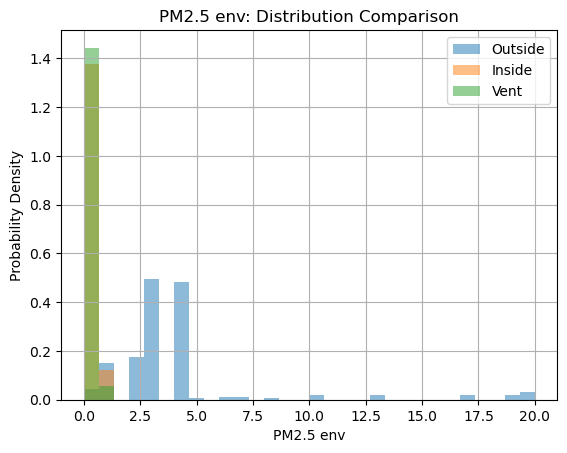

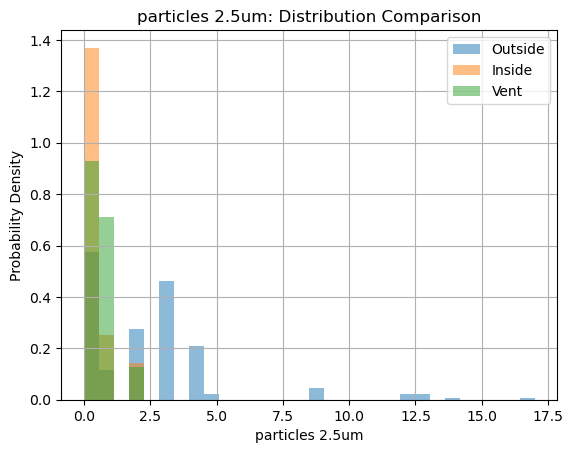

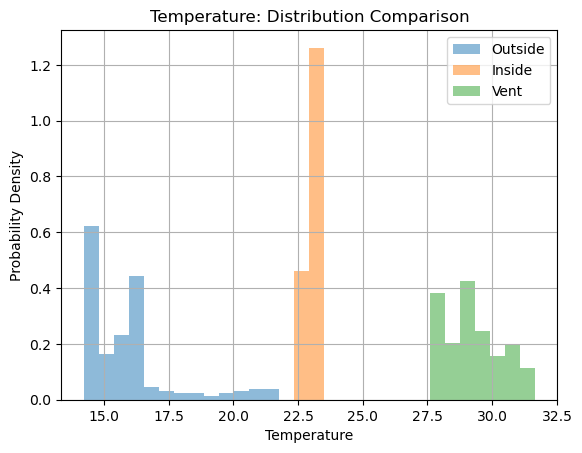

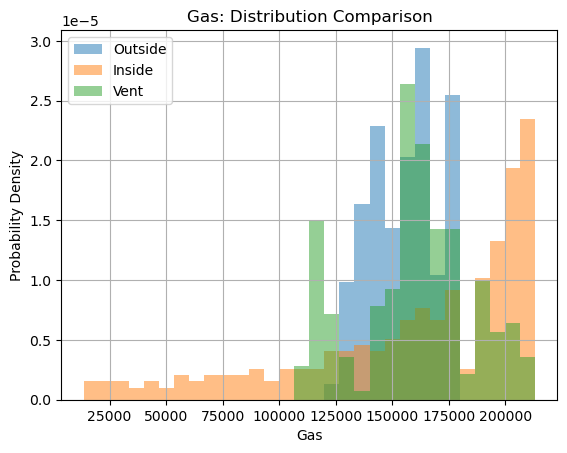

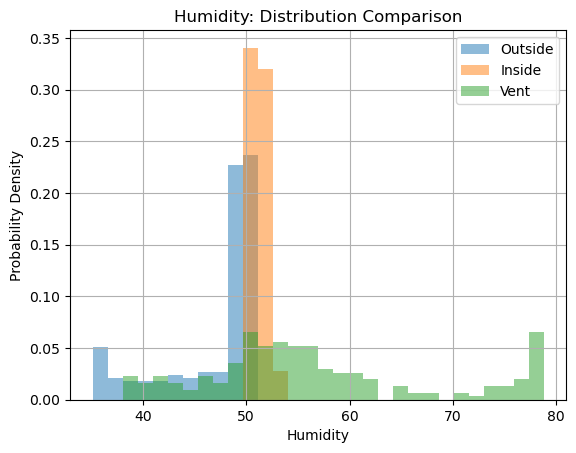

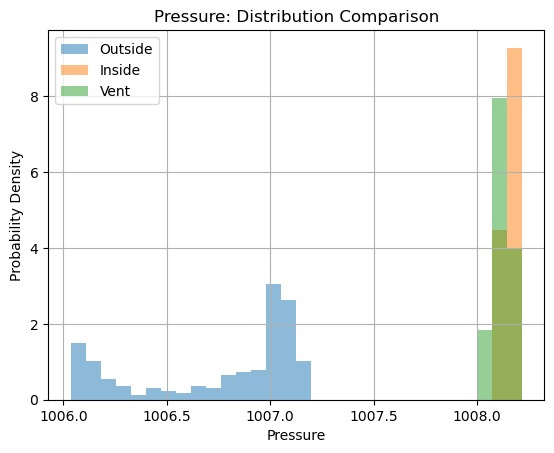

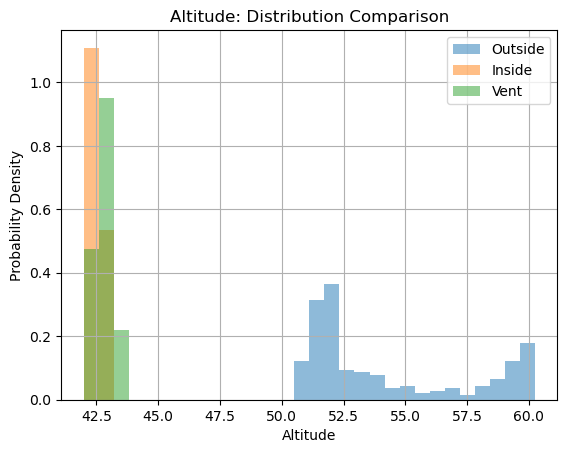

In [57]:
import matplotlib.pyplot as plt
import numpy as np

data_columns = [col for col in df_inside.columns if col != time_column]

for col in data_columns:
    plt.figure()

    # Collect all available data to define common bins
    combined = []

    if col in df_outside.columns:
        combined.append(df_outside[col].dropna())

    if col in df_inside.columns:
        combined.append(df_inside[col].dropna())

    if col in df_vent.columns:
        combined.append(df_vent[col].dropna())

    if not combined:
        continue
    combined = np.concatenate(combined)
    
    bins = np.histogram_bin_edges(combined, bins=30)

    if col in df_outside.columns:
        plt.hist(df_outside[col].dropna(),
                 bins=bins,
                 alpha=0.5,
                 label="Outside",
                 density=True)

    if col in df_inside.columns:
        plt.hist(df_inside[col].dropna(),
                 bins=bins,
                 alpha=0.5,
                 label="Inside",
                 density=True)

    if col in df_vent.columns:
        plt.hist(df_vent[col].dropna(),
                 bins=bins,
                 alpha=0.5,
                 label="Vent",
                 density=True)

    plt.xlabel(col)
    plt.ylabel("Probability Density")
    plt.title(f"{col}: Distribution Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

In [22]:
import pandas as pd
import numpy as np

# Split: inside is (1, 40] seconds, outside is > 40 seconds
df_inside  = df[(df[time_column] > 1) & (df[time_column] <= 40)]
df_outside = df[df[time_column] > 40]

results = []

for col in df.columns[1:]:
    xin = df_inside[col].dropna().to_numpy()
    xout = df_outside[col].dropna().to_numpy()

    Nin, Nout = len(xin), len(xout)
    
    mu_in, mu_out = xin.mean(), xout.mean()

    # sample std dev
    sigma_in  = xin.std(ddof=1)
    sigma_out = xout.std(ddof=1)

    # uncertainty on the mean
    sigma_in_uncertainty  = sigma_in / np.sqrt(Nin)
    sigma_out_uncertainty = sigma_out / np.sqrt(Nout)

    #how many inside measurement sigmas away are the two means

    uncertainty_difference = np.abs(mu_in-mu_out)/sigma_in

    results.append({
        "column": col,
        "N_in": Nin, "N_out": Nout,
        "mean_in": mu_in, "mean_out": mu_out,
        "std_in": sigma_in, "std_out": sigma_out,
        "sigma_in_uncertainty": sigma_in_uncertainty, "sigma_out_uncertainty": sigma_out_uncertainty,
        "inside_sigmas_difference": uncertainty_difference
    })

out = pd.DataFrame(results)
# Nice display ordering (optional)
cols_order = ["column","N_in","N_out","mean_in","mean_out","std_in","std_out","sigma_in_uncertainty", "sigma_out_uncertainty","inside_sigmas_difference"]
cols_order = [c for c in cols_order if c in out.columns]
out = out[cols_order]

print(out.to_string(index=False))

         column  N_in  N_out      mean_in      mean_out       std_in      std_out  sigma_in_uncertainty  sigma_out_uncertainty  inside_sigmas_difference
      PM2.5 env    35    260     0.885714      3.626923     0.322803     3.738979              0.054564               0.231882                  8.491898
particles 2.5um    35    260     0.485714      2.115385     0.507093     2.745680              0.085714               0.170280                  3.213753
    Temperature    35    260    23.275106     16.614220     0.182107     2.676792              0.030782               0.166008                 36.576752
            Gas    35    260 95063.971429 150852.396154 11342.012563 17876.661847           1917.150035            1108.663504                  4.918741
       Humidity    35    260    36.603784     45.510078     1.124208     5.958941              0.190026               0.369558                  7.922286
       Pressure    35    260  1006.741480   1006.720374     0.008150     0.380405 